<a href="https://colab.research.google.com/github/enm0910/ST554/blob/main/EMartinez_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author: Emma Martinez

Course: ST 554 HW#6

Purpose: Homework 6- Practice querying a database and messing with classes

#Part 1- More Practice Querying a Database

###Question #1

In [11]:
# Import libraries
import sqlite3
import pandas as pd

# Connect to database
conn = sqlite3.connect("lahman_1871-2022.sqlite")

# Filter to get tables
q1 = """
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
"""

# Run sql query and return result as dataframe
tables = pd.read_sql(q1, conn)
print(tables)

                   name
0           AllstarFull
1           Appearances
2        AwardsManagers
3         AwardsPlayers
4   AwardsShareManagers
5    AwardsSharePlayers
6               Batting
7           BattingPost
8        CollegePlaying
9              Fielding
10           FieldingOF
11      FieldingOFsplit
12         FieldingPost
13           HallOfFame
14            HomeGames
15             Managers
16         ManagersHalf
17                Parks
18               People
19             Pitching
20         PitchingPost
21             Salaries
22              Schools
23           SeriesPost
24                Teams
25      TeamsFranchises
26            TeamsHalf


###Question #2

In [12]:
# Filter HallOfFame to only inducted players
# Join with Pitching on playerIDs to only get HOF pitchers
# Group by playerID and sum the columns
q2 = """
SELECT
    p.playerID,
    SUM(p.GS)     AS total_GS,     -- Games Started
    SUM(p.G)      AS total_G,      -- Games Pitched
    SUM(p.W)      AS total_W,      -- Wins
    SUM(p.L)      AS total_L,      -- Losses
    SUM(p.IPouts) AS total_IPouts, -- Outs Pitched
    SUM(p.CG)     AS total_CG,     -- Complete Games
    SUM(p.SHO)    AS total_SHO,    -- Shutouts
    SUM(p.SV)     AS total_SV      -- Saves
FROM Pitching p
INNER JOIN HallOfFame hof
    ON p.playerID = hof.playerID
WHERE hof.inducted = 'Y'           -- Only count players actually inducted
GROUP BY p.playerID
ORDER BY total_W DESC;             -- Sort by wins so best pitchers appear first
"""

hof_pitching = pd.read_sql(q2, conn)
print(hof_pitching.head(10))
print(f"Total HOF pitchers found: {len(hof_pitching)}")

    playerID  total_GS  total_G  total_W  total_L  total_IPouts  total_CG  \
0  youngcy01       815      906      511      315         22068       749   
1  johnswa01       666      802      417      279         17744       531   
2  alexape01       599      696      373      208         15570       437   
3  mathech01       552      636      373      188         14366       435   
4  galvipu01       688      705      365      310         18010       646   
5  spahnwa01       665      750      363      245         15731       382   
6  nichoki01       562      621      362      208         15202       532   
7  maddugr01       740      744      355      227         15025       109   
8  keefeti01       594      600      342      225         15149       554   
9  carltst01       709      741      329      244         15652       254   

   total_SHO  total_SV  
0         76        18  
1        110        34  
2         90        32  
3         79        29  
4         57         2  
5 

###Question #3

In [13]:
# Join HOF pitchers on batting to get only their batting statistics
q3 = """
SELECT
    b.playerID,
    SUM(b.AB)  AS total_AB,   -- At Bats
    SUM(b.R)   AS total_R,    -- Runs Scored
    SUM(b.H)   AS total_H,    -- Hits
    SUM(b.HR)  AS total_HR,   -- Home Runs
    SUM(b.RBI) AS total_RBI,  -- Runs Batted In
    SUM(b.BB)  AS total_BB,   -- Walks
    SUM(b.SO)  AS total_SO    -- Strikeouts
FROM Batting b
INNER JOIN HallOfFame hof
    ON b.playerID = hof.playerID
WHERE hof.inducted = 'Y'
GROUP BY b.playerID
ORDER BY total_H DESC;        -- Sort by hits
"""

hof_batting = pd.read_sql(q3, conn)
print(hof_batting.head(10))
print(f"Total players with batting records: {len(hof_batting)}")

    playerID  total_AB  total_R  total_H  total_HR  total_RBI  total_BB  \
0   cobbty01     11436     2247     4189       117       1944      1249   
1  aaronha01     12364     2174     3771       755       2297      1402   
2  musiast01     10972     1949     3630       475       1951      1599   
3  speaktr01     10195     1882     3514       117       1529      1381   
4  jeterde01     11195     1923     3465       260       1311      1082   
5  ansonca01     10281     1999     3435        97       2075       984   
6  wagneho01     10439     1739     3420       101       1733       963   
7  yastrca01     11988     1816     3419       452       1844      1845   
8  molitpa01     10835     1782     3319       234       1307      1094   
9  collied01      9949     1821     3315        47       1300      1499   

   total_SO  
0       608  
1      1383  
2       696  
3       323  
4      1840  
5       330  
6       735  
7      1393  
8      1244  
9       400  
Total players with b

###Question #4

In [14]:
# Join two tables (pitching and batting stats) by pitcher
hof_combined = pd.merge(
    hof_pitching,   # Pitching stats
    hof_batting,    # Batting stats
    on='playerID',  # Column to match
    how='inner'
)

print(hof_combined.head(10))
print(f"Shape: {hof_combined.shape}")
print(f"Columns: {list(hof_combined.columns)}")

# Close connection
conn.close()

    playerID  total_GS  total_G  total_W  total_L  total_IPouts  total_CG  \
0  youngcy01       815      906      511      315         22068       749   
1  johnswa01       666      802      417      279         17744       531   
2  alexape01       599      696      373      208         15570       437   
3  mathech01       552      636      373      188         14366       435   
4  galvipu01       688      705      365      310         18010       646   
5  spahnwa01       665      750      363      245         15731       382   
6  nichoki01       562      621      362      208         15202       532   
7  maddugr01       740      744      355      227         15025       109   
8  keefeti01       594      600      342      225         15149       554   
9  carltst01       709      741      329      244         15652       254   

   total_SHO  total_SV  total_AB  total_R  total_H  total_HR  total_RBI  \
0         76        18      2960      325      623        18        290   
1 

#Part 2- Messing with Classes

###Question #5

Please call run_simulations() first.


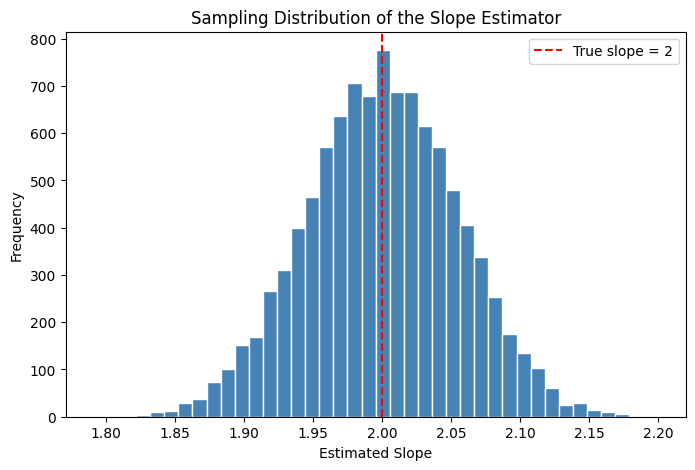

Two-sided P ≈ 2 × 0.0352 = 0.0704
[2.0239168  1.99560551 2.04249093 ... 1.93451109 2.01445559 2.07173587]


In [15]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from sklearn import linear_model

class SLR_slope_simulator:
    """
    Simulates the sampling distribution of the slope estimator
    in a Simple Linear Regression (SLR) model.
    The model is: Y = beta_0 + beta_1 * X + E,  E ~ N(0, sigma^2)
    """

# Store model parameters and initialize mutable state
# Use a seeded generator for reproducibility
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.sigma  = sigma
        self.x      = x
        self.n      = len(x)
        self.rng    = default_rng(seed)
        self.slopes = []

# Simulate one dataset under true SLR model
    def generate_data(self):
        noise = self.sigma * self.rng.standard_normal(self.n)
        y = self.beta_0 + self.beta_1 * self.x + noise
        return self.x, y

# Fit OLS regression and return slope coefficient
    def fit_slope(self, x, y):
        reg = linear_model.LinearRegression()
        reg.fit(x.reshape(-1, 1), y)
        return reg.coef_[0]

# Repeatedly sample from model and return slope estimates
    def run_simulations(self, num_simulations):
        slope_estimates = []
        for i in range(num_simulations):

            # Generate a random dataset
            x, y = self.generate_data()

            # Fit the model and get the slope estimate
            slope = self.fit_slope(x, y)

            # Save the estimate
            slope_estimates.append(slope)

        # Convert list to NumPy array and store in the attribute
        self.slopes = np.array(slope_estimates)

    # Guard against calling before simulations have been run + overlay true parameter value as a reference line for bias assessment
    def plot_sampling_distribution(self):

        # Guard clause: check if any slopes are stored yet
        if len(self.slopes) == 0:
            print("Please call run_simulations() first.")
            return

        plt.figure(figsize=(8, 5))
        plt.hist(self.slopes, bins=40, color='steelblue', edgecolor='white')

        # Add a vertical line at the true slope for reference
        plt.axvline(self.beta_1, color='red', linestyle='--',
                    label=f'True slope = {self.beta_1}')
        plt.title('Sampling Distribution of the Slope Estimator')
        plt.xlabel('Estimated Slope')
        plt.ylabel('Frequency')
        plt.legend()
        plt.show()


# Approximate tail probabilities from the simulated distribution
    def find_prob(self, value, sided):

        # Guard clause: need slopes first
        if len(self.slopes) == 0:
            print("Please call run_simulations() first.")
            return None

        if sided == 'above':
            # Proportion of simulated slopes above value
            prob = (self.slopes > value).mean()
            print(f'P(slope > {value}) ≈ {prob:.4f}')

        elif sided == 'below':
            # Proportion of simulated slopes below value
            prob = (self.slopes < value).mean()
            print(f'P(slope < {value}) ≈ {prob:.4f}')

        elif sided == 'two-sided':
            median = np.median(self.slopes)

            if value > median:
                # Value is in the upper tail → double the right-tail probability
                one_tail = (self.slopes > value).mean()
                prob = 2 * one_tail
            else:
                # Value is in the lower tail → double the left-tail probability
                one_tail = (self.slopes < value).mean()
                prob = 2 * one_tail

            print(f'Two-sided P ≈ 2 × {one_tail:.4f} = {prob:.4f}')

        return prob


# TEST CODE FOR MY CLASS AND METHODS

# Validate all methods, then exercise full simulation and reporting
x_vals = np.array(list(np.linspace(start=0, stop=10, num=11)) * 3)

# Create object with specified parameters
sim = SLR_slope_simulator(
    beta_0 = 12,
    beta_1 = 2,
    x      = x_vals,
    sigma  = 1,
    seed   = 10
)

# Plot before running simulations to print the error message
sim.plot_sampling_distribution()

# Run 10,000 simulations
sim.run_simulations(10000)

# Plot the sampling distribution
sim.plot_sampling_distribution()

# Approximate the two-sided probability for value = 2.1
sim.find_prob(value=2.1, sided='two-sided')

# Print the slopes array
print(sim.slopes)